# 🌾 Model 2 — Yield Prediction
### AI-Powered Smart Farming Assistant (Kerala-focused)

**Type:** Classical ML — regression
**Algorithm:** Random Forest / Gradient Boosting Regressor (best of several, chosen automatically)
**Feeds into:** the `yield_prediction_model` tool in the agentic pipeline (Phase 3 of the Agent Dev Guide)

---

## ⚠️ Read this before running anything

**Do not use a GPU runtime.** Same reasoning as Model 1: this is tabular regression, not deep
learning. `Runtime → Change runtime type → Hardware accelerator → None (CPU)`. Save your GPU hours
for Model 3 (Disease Detection CNN).

## Important correction from the earlier planning document

The original "Advanced AI Implementation Prompt" document assumed inputs of
`[State, District, Crop, temperature, humidity, rainfall]`. The real dataset available for this task
doesn't have district-level rows or temperature/humidity — it has **State-level** data with
**Annual_Rainfall**. It also has `Fertilizer`, `Pesticide`, `Area`, and `Production` columns, which
this notebook **deliberately excludes from the model's inputs**:

- `Fertilizer` / `Pesticide` are usage *totals* recorded after the season — a farmer asking for a
  yield estimate *before planting* doesn't know these yet. Using them as inputs would mean the tool
  can't actually be called with real, available data.
- `Area` and `Production` are used to *compute* `Yield` (`Yield = Production / Area`) — including
  either as an input feature would leak the answer into the prediction, producing a misleadingly high
  accuracy that collapses the moment it's used for real.

**Final input features: `Crop`, `Season`, `State`, `Annual_Rainfall`.** These are the only things
genuinely known before a season starts.


## 1 · Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, json, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not available -- will use sklearn's GradientBoostingRegressor instead.")

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Setup complete.")


Setup complete.


## 2 · Load Dataset

**Primary method:** `kagglehub` -- same dataset already referenced in the ML Models document.
This dataset does not have a verified zero-auth CSV mirror the way the Crop Recommendation dataset
did, so if `kagglehub` fails for you, the fallback is a **manual upload**: download the CSV from
either the Kaggle page or the Mendeley Data release below, then upload it directly in Colab.

- Kaggle: `akshatgupta7/crop-yield-in-indian-states-dataset`
- Mendeley Data (verified academic mirror, same schema): https://data.mendeley.com/datasets/ncw2vbcgnk/2


In [ ]:
df = None

# --- Method 1: kagglehub (recommended) ---
try:
    import kagglehub
    path = kagglehub.dataset_download("akshatgupta7/crop-yield-in-indian-states-dataset")
    csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
    assert csv_files, "No CSV found in downloaded dataset folder."
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"Loaded via kagglehub: {df.shape}, file: {csv_files[0]}")
except Exception as e:
    print(f"kagglehub method failed ({type(e).__name__}) -- use the manual upload cell below instead.")

df.head() if df is not None else print("df is None -- run the manual upload cell below.")


100%|██████████| 476k/476k [00:00<00:00, 80.1MB/s]

Extracting files...
Loaded via kagglehub: (19689, 10), file: crop_yield.csv


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [ ]:
# --- Method 2: manual upload fallback (only run this cell if Method 1 failed) ---
# Uncomment and run if needed:

# from google.colab import files
# uploaded = files.upload()  # choose the CSV you downloaded from Kaggle or Mendeley
# filename = list(uploaded.keys())[0]
# df = pd.read_csv(filename)
# print(f"Loaded via manual upload: {df.shape}")
# df.head()


## 3 · Inspect and Standardize Column Names

In [ ]:
print("Columns found:", list(df.columns))
print("\nShape:", df.shape)
df.head()


Columns found: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [ ]:
# Different re-uploads of this dataset sometimes vary column casing/spacing --
# normalize defensively so the rest of the notebook doesn't break on that.
df.columns = [c.strip() for c in df.columns]

expected = ["Crop", "Crop_Year", "Season", "State", "Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide", "Yield"]
missing = [c for c in expected if c not in df.columns]
if missing:
    print(f"WARNING: expected columns not found: {missing}")
    print("Check df.columns above and adjust the rename map below if names differ slightly.")
else:
    print("All expected columns present.")


All expected columns present.


## 4 · Exploratory Data Analysis

In [ ]:
print("Missing values:\n", df.isnull().sum())
print("\nStates covered:", df['State'].nunique())
print("Crops covered:", df['Crop'].nunique())
print("Year range:", df['Crop_Year'].min(), "-", df['Crop_Year'].max())
print("\nRows for Kerala:", (df['State'] == 'Kerala').sum())


Missing values:
 Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

States covered: 30
Crops covered: 55
Year range: 1997 - 2020

Rows for Kerala: 534


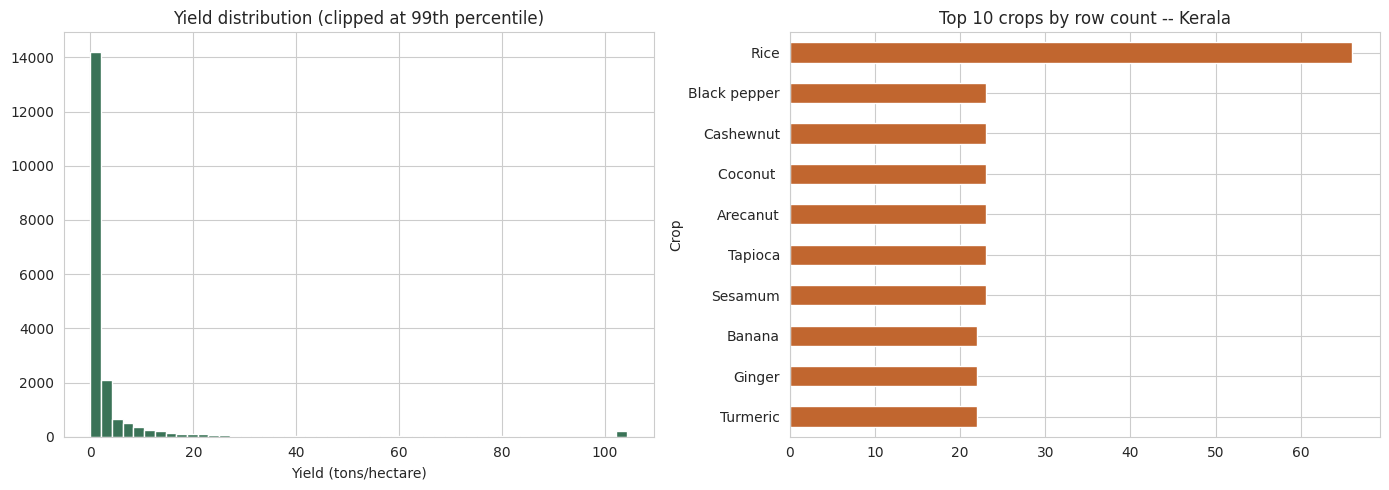

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Yield'].clip(upper=df['Yield'].quantile(0.99)).hist(bins=50, ax=axes[0], color='#3A7357')
axes[0].set_title("Yield distribution (clipped at 99th percentile)")
axes[0].set_xlabel("Yield (tons/hectare)")

kerala_crops = df[df['State'] == 'Kerala']['Crop'].value_counts().head(10)
kerala_crops.plot(kind='barh', ax=axes[1], color='#C1662F')
axes[1].set_title("Top 10 crops by row count -- Kerala")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 5 · Clean Data and Select Leakage-Safe Features

Dropping rows with missing/zero Area or Production (can't compute a valid Yield from those), and
removing extreme outliers that are almost always data-entry errors in this dataset (e.g. Yield values
several orders of magnitude above realistic crop yields).


In [ ]:
df_clean = df.dropna(subset=['Crop', 'Season', 'State', 'Annual_Rainfall', 'Yield']).copy()
df_clean = df_clean[(df_clean['Area'] > 0) & (df_clean['Production'] > 0)]

# Remove extreme outliers using the IQR method on Yield
q1, q3 = df_clean['Yield'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 3 * iqr
before = len(df_clean)
df_clean = df_clean[df_clean['Yield'] <= upper_bound]
print(f"Removed {before - len(df_clean)} outlier rows ({(before - len(df_clean))/before*100:.1f}%)")

# Leakage-safe feature set -- see the correction note at the top of this notebook
FEATURES = ['Crop', 'Season', 'State', 'Annual_Rainfall']
TARGET = 'Yield'

df_model = df_clean[FEATURES + [TARGET]].copy()
df_model['Season'] = df_model['Season'].str.strip()
print(f"\nFinal modeling dataset: {df_model.shape}")
df_model.head()


Removed 2315 outlier rows (11.8%)

Final modeling dataset: (17262, 5)


,Crop,Season,State,Annual_Rainfall,Yield
0,Arecanut,Whole Year,Assam,2051.4,0.796087
1,Arhar/Tur,Kharif,Assam,2051.4,0.710435
2,Castor seed,Kharif,Assam,2051.4,0.238333
4,Cotton(lint),Kharif,Assam,2051.4,0.420909
5,Dry chillies,Whole Year,Assam,2051.4,0.643636


## 6 · Train / Test Split

In [ ]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (13809, 4), Test: (3453, 4)


## 7 · Preprocessing Pipeline

Per the original implementation prompt's requirement: the encoder is built directly into a
scikit-learn `Pipeline`, so the exported file handles raw categorical input (crop names, season names,
state names as plain strings) without a separate encoder file to keep in sync.


In [ ]:
categorical_features = ['Crop', 'Season', 'State']
numeric_features = ['Annual_Rainfall']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numeric_features),
])
print("Preprocessor defined.")


Preprocessor defined.


## 8 · Baseline Model Comparison

In [ ]:
candidates = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
if XGB_AVAILABLE:
    candidates["XGBoost"] = XGBRegressor(random_state=RANDOM_STATE)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, regressor in candidates.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', regressor)])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    results.append({"Model": name, "Mean CV R2": scores.mean(), "Std": scores.std()})

leaderboard = pd.DataFrame(results).sort_values("Mean CV R2", ascending=False).reset_index(drop=True)
leaderboard


,Model,Mean CV R2,Std
0,XGBoost,0.821878,0.009896
1,Random Forest,0.816131,0.013514
2,Decision Tree,0.730876,0.020782
3,Linear Regression,0.618471,0.015448
4,Gradient Boosting,0.613892,0.017842


## 9 · Hyperparameter Tuning

In [ ]:
rf_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])

rf_param_grid = {
    "regressor__n_estimators": [150, 250, 350],
    "regressor__max_depth": [None, 15, 25],
    "regressor__min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=kf, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)


Best Random Forest params: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 350}
Best CV R2: 0.8255829042651037


In [ ]:
if XGB_AVAILABLE:
    gb_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', XGBRegressor(random_state=RANDOM_STATE))])
    gb_param_grid = {
        "regressor__n_estimators": [150, 250],
        "regressor__max_depth": [4, 6, 8],
        "regressor__learning_rate": [0.05, 0.1],
    }
else:
    gb_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=RANDOM_STATE))])
    gb_param_grid = {
        "regressor__n_estimators": [150, 250],
        "regressor__max_depth": [3, 5],
        "regressor__learning_rate": [0.05, 0.1],
    }

gb_grid = GridSearchCV(gb_pipe, gb_param_grid, cv=kf, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print("Best Gradient Boosting params:", gb_grid.best_params_)
print("Best CV R2:", gb_grid.best_score_)


Best Gradient Boosting params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 8, 'regressor__n_estimators': 250}
Best CV R2: 0.8246691400014461


In [ ]:
if rf_grid.best_score_ >= gb_grid.best_score_:
    best_pipeline = rf_grid.best_estimator_
    best_model_name = "Random Forest"
else:
    best_pipeline = gb_grid.best_estimator_
    best_model_name = "XGBoost" if XGB_AVAILABLE else "Gradient Boosting"

print(f"Selected model: {best_model_name}")


Selected model: Random Forest


## 10 · Final Evaluation (held-out test set)

In [ ]:
y_pred = best_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R2:   {r2:.4f}")
print(f"Test RMSE: {rmse:.4f} tons/hectare")
print(f"Test MAE:  {mae:.4f} tons/hectare")


Test R2:   0.8223
Test RMSE: 0.5862 tons/hectare
Test MAE:  0.2966 tons/hectare


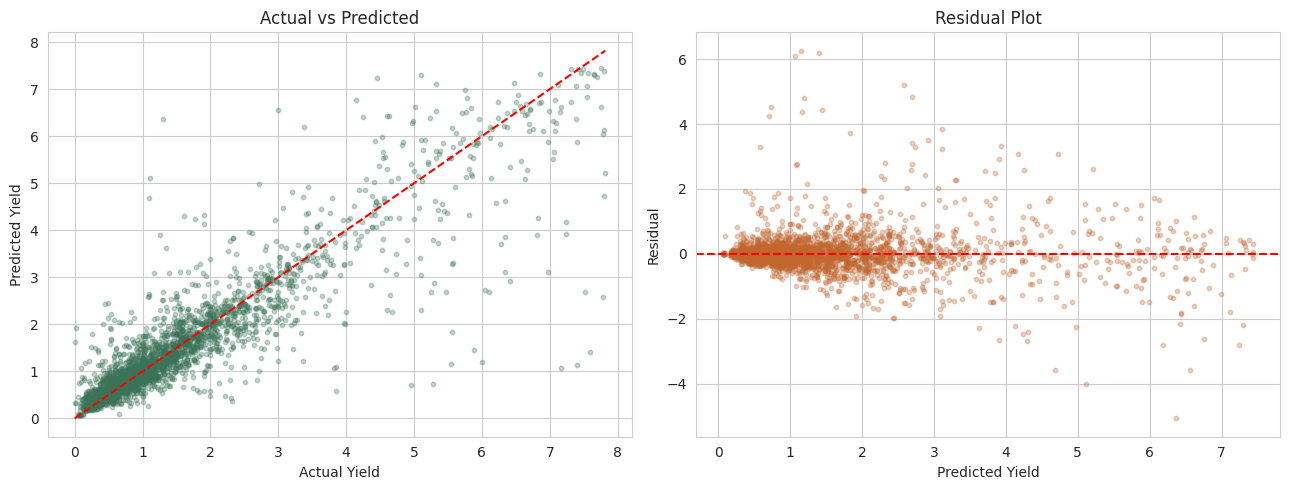

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#3A7357')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[0].set_xlabel("Actual Yield"); axes[0].set_ylabel("Predicted Yield")
axes[0].set_title("Actual vs Predicted")

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='#C1662F')
axes[1].axhline(0, color='r', linestyle='--', lw=1.5)
axes[1].set_xlabel("Predicted Yield"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()


## 11 · Kerala-Specific Evaluation

Trained on the full national dataset for statistical robustness (same "train broad" approach used for
Model 1), but evaluated separately on Kerala rows -- honest reporting of regional accuracy rather than
assuming national performance transfers uniformly.


In [17]:
kerala_mask_test = X_test['State'] == 'Kerala'

if kerala_mask_test.sum() > 5:
    kerala_r2 = r2_score(y_test[kerala_mask_test], y_pred[kerala_mask_test])
    kerala_rmse = np.sqrt(mean_squared_error(y_test[kerala_mask_test], y_pred[kerala_mask_test]))
    print(f"Kerala-only test rows: {kerala_mask_test.sum()}")
    print(f"Kerala-only R2:   {kerala_r2:.4f}")
    print(f"Kerala-only RMSE: {kerala_rmse:.4f} tons/hectare")
    print("\nIf this is noticeably weaker than the overall test score, report both numbers honestly")
    print("in the project report rather than only the stronger national figure.")
else:
    print(f"Only {kerala_mask_test.sum()} Kerala rows in the test split -- too few for a separate")
    print("reliable metric. Report the overall test score and note this limitation explicitly.")


Kerala-only test rows: 75
Kerala-only R2:   0.8059
Kerala-only RMSE: 0.6162 tons/hectare

If this is noticeably weaker than the overall test score, report both numbers honestly
in the project report rather than only the stronger national figure.


## 12 · Feature Importance

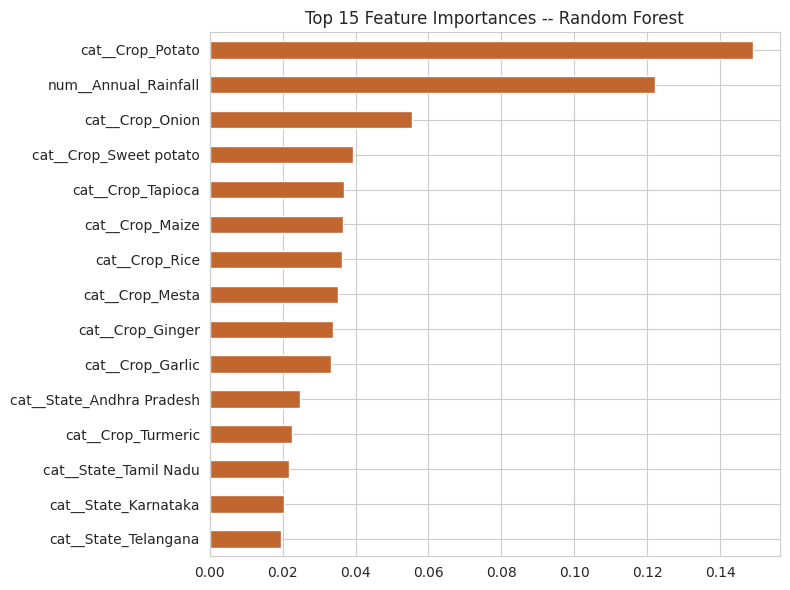

In [18]:
if best_model_name in ("Random Forest", "XGBoost", "Gradient Boosting"):
    regressor = best_pipeline.named_steps['regressor']
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = pd.Series(regressor.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    importances.plot(kind='barh', color='#C1662F')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances -- {best_model_name}")
    plt.tight_layout()
    plt.show()


## 13 · Export Model

Exports a **single file** containing both the preprocessing (OneHotEncoder) and the trained
regressor, bundled as one scikit-learn Pipeline -- simpler than maintaining a separate encoder file,
and matches the original prompt's request to keep the transformation pipeline built into the model
object.


In [19]:
os.makedirs("yield_prediction_model", exist_ok=True)

joblib.dump(best_pipeline, "yield_prediction_model/crop_yield_pipeline.pkl")

metadata = {
    "model_name": best_model_name,
    "feature_order": FEATURES,
    "target": TARGET,
    "target_unit": "tons/hectare",
    "test_r2": round(float(r2), 4),
    "test_rmse": round(float(rmse), 4),
    "kerala_test_r2": round(float(kerala_r2), 4) if kerala_mask_test.sum() > 5 else None,
    "states_covered": sorted(df_model['State'].unique().tolist()),
    "crops_covered": sorted(df_model['Crop'].unique().tolist()),
    "seasons_covered": sorted(df_model['Season'].unique().tolist()),
}
with open("yield_prediction_model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2)[:800], "...")


{
  "model_name": "Random Forest",
  "feature_order": [
    "Crop",
    "Season",
    "State",
    "Annual_Rainfall"
  ],
  "target": "Yield",
  "target_unit": "tons/hectare",
  "test_r2": 0.8223,
  "test_rmse": 0.5862,
  "kerala_test_r2": 0.8059,
  "states_covered": [
    "Andhra Pradesh",
    "Arunachal Pradesh",
    "Assam",
    "Bihar",
    "Chhattisgarh",
    "Delhi",
    "Goa",
    "Gujarat",
    "Haryana",
    "Himachal Pradesh",
    "Jammu and Kashmir",
    "Jharkhand",
    "Karnataka",
    "Kerala",
    "Madhya Pradesh",
    "Maharashtra",
    "Manipur",
    "Meghalaya",
    "Mizoram",
    "Nagaland",
    "Odisha",
    "Puducherry",
    "Punjab",
    "Sikkim",
    "Tamil Nadu",
    "Telangana",
    "Tripura",
    "Uttar Pradesh",
    "Uttarakhand",
    "West Bengal"
  ],
  "crops_ ...


In [20]:
import shutil
shutil.make_archive("yield_prediction_model", 'zip', "yield_prediction_model")

try:
    from google.colab import files
    files.download("yield_prediction_model.zip")
    print("Download triggered.")
except ImportError:
    print("Not running in Colab -- find yield_prediction_model.zip in the working directory.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.


## 14 · Inference Function (matches yield_tool.py exactly)

In [21]:
def predict_yield(crop, season, state, annual_rainfall, farm_area_hectares):
    input_df = pd.DataFrame([{
        "Crop": crop, "Season": season, "State": state, "Annual_Rainfall": annual_rainfall,
    }])

    yield_per_hectare = float(best_pipeline.predict(input_df)[0])
    total_estimated_harvest = yield_per_hectare * farm_area_hectares

    return {
        "yield_per_hectare": round(yield_per_hectare, 2),
        "total_estimated_harvest": round(total_estimated_harvest, 2),
        "unit": "tons",
    }

# demo -- coconut, Kerala, monsoon season, 1 hectare
predict_yield(crop="Coconut", season="Whole Year", state="Kerala", annual_rainfall=2800, farm_area_hectares=1.0)


{'yield_per_hectare': 0.71, 'total_estimated_harvest': 0.71, 'unit': 'tons'}

---
## Summary

- **Model:** best of Linear Regression / Random Forest / Gradient Boosting / XGBoost, chosen by cross-validation
- **Inputs:** Crop, Season, State, Annual_Rainfall -- all knowable *before* a season starts, no leakage
- **Output:** yield per hectare + total estimated harvest for the farmer's actual land size
- **Files exported:** `crop_yield_pipeline.pkl` (encoder + model bundled together), `metadata.json`
- **Kerala performance reported separately** from national performance -- check this before claiming
  high accuracy in the report; if Kerala-specific R² is meaningfully lower, say so.

**Next step:** update `yield_tool.py` to load `crop_yield_pipeline.pkl` as a single file (see chat) --
this replaces the two-file `model.pkl` + `encoder.pkl` assumption from the original Agent Dev Guide.
